<a href="https://colab.research.google.com/github/HudaSaffo/fashion-recommendation-system/blob/week8-outfit-scoring/outfit_scoring_and_ranking.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 8 — Outfit Scoring and Recommendation Ranking

This notebook ranks the candidate outfits from Week 6 using query relevance, item compatibility, color harmony, price fit, category completeness, and style coherence. It applies a diversity penalty to reduce repeated products and displays matching Week 7 collages when available.

The results include score breakdowns and explanations. A retrieval-only comparison evaluates the ranking, and the final results are exported as JSON and CSV files.

## 1. Setup
Import the required libraries and define the paths for Week 6 results, catalog data, Week 7 collages, and Week 8 outputs.

In [2]:
from pathlib import Path
from itertools import combinations
from dataclasses import dataclass, field, replace
from copy import deepcopy
import json, math, re, sys
import pandas as pd
from IPython.display import display, Image
ROOT = Path('/content/drive/MyDrive') if 'google.colab' in sys.modules else Path.cwd()
OUT = ROOT / 'outputs' / 'week8'
OUT.mkdir(parents=True, exist_ok=True)
WEEK6_JSON = ROOT / 'week6_results.json'
CATALOG = ROOT / 'catalog_refined.parquet'
COLLAGE_DIR = ROOT / 'week7_two_column' / 'real'


## 2. Load Candidate Outfits
Load the saved Week 6 results and display the number of queries and candidate outfits.

In [3]:
results = json.loads(WEEK6_JSON.read_text(encoding="utf-8"))

print(
    f"Loaded {len(results)} queries and "
    f"{sum(len(r['top_outfits']) for r in results)} candidate outfits."
)

Loaded 5 queries and 25 candidate outfits.


## 3. Ranking Settings
Define the scoring weights, number of recommendations, diversity penalty, and budget settings.

In [4]:
@dataclass
class RankingConfig:
    weights: dict = field(default_factory=lambda: dict(query_relevance=.30,
        item_compatibility=.25, color_harmony=.15, price_fit=.10,
        category_completeness=.10, style_coherence=.10))
    top_k: int = 3
    diversity_strength: float = .15
    product_similarity_weight: float = .8
    retrieval_scale: float = 8.0  # Week 6 item_relevance normalization
    unknown_score: float = .5
    total_budget_mode: bool = False
    total_budget: float | None = None
    availability_field: str | None = None

    def __post_init__(self):
        expected = {'query_relevance','item_compatibility','color_harmony','price_fit',
                    'category_completeness','style_coherence'}
        if set(self.weights) != expected or any(not math.isfinite(v) or v < 0 for v in self.weights.values()) or not math.isclose(sum(self.weights.values()),1):
            raise ValueError('Use the six named nonnegative weights summing to one.')
        if self.top_k < 1 or not 0 <= self.diversity_strength <= 1 or not 0 <= self.product_similarity_weight <= 1:
            raise ValueError('Invalid selection settings.')
        if self.retrieval_scale <= 0 or not 0 <= self.unknown_score < 1:
            raise ValueError('Use a positive retrieval scale and unknown score below one.')
        if self.total_budget_mode and (self.total_budget is None or not math.isfinite(self.total_budget) or self.total_budget < 0):
            raise ValueError('Explicit total budget required in total-outfit mode.')

config = RankingConfig()


## 4. Prepare Product Information
Reuse Week 6’s product details and add existing outfit memberships and configured availability information from the catalog.

In [5]:
def clean(value):
    return '' if value is None or (isinstance(value, float) and math.isnan(value)) else str(value).strip().lower()

def tags(value):
    if value is None: return set()
    values = value if isinstance(value, (list, tuple, set)) or hasattr(value, 'tolist') else re.split(r'[,|]', str(value))
    return {clean(v).replace('-', ' ') for v in values if clean(v)}

def number(value):
    if value is None or clean(value) == '': return None
    value = float(value)
    return value if math.isfinite(value) and value >= 0 else None

columns = ['item_id', 'set_id']
if config.availability_field:
    columns.append(config.availability_field)
frame = pd.read_parquet(CATALOG, columns=columns)
frame['item_id'] = frame['item_id'].astype(str)
memberships = frame.groupby('item_id')['set_id'].agg(
    lambda values: sorted(set(values.dropna().astype(str)))
).to_dict()
availability = (
    frame.drop_duplicates('item_id').set_index('item_id')[config.availability_field].to_dict()
    if config.availability_field else {}
)

def hydrate(result):
    outfits = deepcopy(result['top_outfits'])
    for outfit in outfits:
        if not outfit.get('items'):
            raise ValueError('Each candidate needs items.')
        for product in outfit['items'].values():
            pid = str(product['product_id'])
            product['outfit_ids'] = sorted(set(product.get('outfit_ids', [])) | set(memberships.get(pid, [])))
            if config.availability_field and pid in availability:
                product[config.availability_field] = availability[pid]
    return outfits


## 5. Filter Eligible Outfits
Exclude outfits with missing required categories, duplicate products, known unavailable items, or unverifiable or unmet budget limits.

In [6]:
def stock(product, cfg):
    if cfg.availability_field is None: return 'unknown'
    value = clean(product.get(cfg.availability_field))
    if value in {'true','1','available','in stock','in_stock'}: return 'available'
    if value in {'false','0','unavailable','out of stock','out_of_stock','sold out'}: return 'unavailable'
    return 'unknown'

def budget_status(outfit, intent, cfg):
    prices = [number(p.get('price')) for p in outfit['items'].values()]
    pc = intent.get('price_constraints') or {}
    low, high = pc.get('minimum'), pc.get('maximum')
    if cfg.total_budget_mode: low, high = None, cfg.total_budget
    if low is None and high is None: return 'not_requested'
    if low is not None and (low < 0 or not math.isfinite(low)) or high is not None and (high < 0 or not math.isfinite(high)) or low is not None and high is not None and low > high:
        raise ValueError('Invalid budget range.')
    if any(p is None for p in prices): return 'unknown_prices'
    values = [sum(prices)] if cfg.total_budget_mode else prices
    return 'compliant' if all((low is None or v >= low) and (high is None or v <= high) for v in values) else 'over_or_under_budget'

def eligibility(outfit, intent, required, cfg):
    items = outfit['items']; ids = [str(p['product_id']) for p in items.values()]
    errors = []
    if not set(required) <= set(items): errors.append('missing required categories')
    if 'dresses' in items and ({'tops','bottoms'} & set(items)): errors.append('dress/separates conflict')
    if len(ids) != len(set(ids)): errors.append('repeated product within outfit')
    if any(stock(p, cfg) == 'unavailable' for p in items.values()): errors.append('known unavailable product')
    status = budget_status(outfit, intent, cfg)
    if status not in {'compliant','not_requested'}: errors.append(status)
    return errors


## 6. Calculate Outfit Scores
Score each outfit using query relevance, item compatibility, color harmony, price fit, category completeness, and style coherence. Record supporting reasons and missing information.

In [7]:
NEUTRAL = {'black','white','cream','beige','grey','gray','navy','brown','ivory','tan'}

def score_outfit(outfit, intent, required, cfg):
    products = list(outfit['items'].values()); pairs = list(combinations(products, 2))
    notes, evidence = [], {}
    def pair_score(key, predicate):
        values, observed = [], 0
        for a, b in pairs:
            left, right = tags(a.get(key)), tags(b.get(key))
            known = bool(left and right)
            values.append(float(predicate(left,right)) if known else cfg.unknown_score)
            observed += known
        evidence[key] = observed / len(pairs) if pairs else 0.
        if observed < len(pairs) or not pairs: notes.append(f'{key}: incomplete pairwise evidence')
        return sum(values)/len(values) if values else cfg.unknown_score
    color = pair_score('color', lambda a,b: bool(a & b or a & NEUTRAL or b & NEUTRAL or 'multi/neutral' in a | b))
    style = pair_score('style', lambda a,b: bool(a & b))
    occasion = pair_score('occasion', lambda a,b: bool(a & b))
    season = pair_score('season', lambda a,b: bool(a & b or 'all season' in a | b))
    shared = sum(bool(set(a.get('outfit_ids',[])) & set(b.get('outfit_ids',[]))) for a,b in pairs)/len(pairs) if pairs else 0.
    compatibility = (occasion+season)/2
    compatibility += .2 * shared * (1-compatibility)
    retrieval = [number(p.get('week5_score')) for p in products]
    if all(v is not None for v in retrieval):
        relevance = sum(min(v/cfg.retrieval_scale,1) for v in retrieval)/len(retrieval)
    elif 'item_relevance' in outfit.get('score_breakdown', {}):
        relevance = float(outfit['score_breakdown']['item_relevance'])
        if not 0 <= relevance <= 1: raise ValueError('Saved relevance must be in [0,1].')
        notes.append('query_relevance: rounded aggregate saved by Week 6; individual retrieval scores unavailable')
    else:
        relevance = sum(cfg.unknown_score if v is None else min(v/cfg.retrieval_scale,1) for v in retrieval)/len(retrieval)
        notes.append('query_relevance: missing retrieval scores use neutral prior')
    budget = budget_status(outfit, intent, cfg)
    price = 1. if budget == 'compliant' else 0. if budget == 'over_or_under_budget' else cfg.unknown_score
    if budget == 'not_requested': notes.append('price_fit: no budget requested; neutral score')
    if any(number(p.get('price')) is None for p in products): notes.append('Individual prices missing; saved total is not per-product budget evidence')
    components = dict(query_relevance=relevance, item_compatibility=compatibility,
        color_harmony=color, price_fit=price,
        category_completeness=len(set(required)&set(outfit['items']))/len(required), style_coherence=style)
    statuses = {str(p['product_id']): stock(p,cfg) for p in products}
    if 'unknown' in statuses.values(): notes.append('Availability unknown for some or all products')
    reasons = ['All required categories present'] if components['category_completeness'] == 1 else []
    if evidence['color'] == 1 and color >= .7: reasons.append('Catalog colors satisfy same/neutral-color heuristic')
    if evidence['style'] == 1 and style >= .7: reasons.append('Catalog style tags agree across item pairs')
    if shared: reasons.append('Some products share a catalog outfit')
    if budget == 'compliant': reasons.append('Known prices satisfy the requested budget')
    return dict(items=deepcopy(outfit['items']), product_ids={k:p['product_id'] for k,p in outfit['items'].items()},
        original_rank=outfit.get('rank'), base_outfit_score=sum(cfg.weights[k]*v for k,v in components.items()),
        components=components, evidence_coverage=evidence, reasons=reasons, missing_data_notes=notes,
        availability=statuses, budget_status=budget,
        collage_path=str(outfit['collage_path']) if outfit.get('collage_path') and Path(outfit['collage_path']).is_file() else None)


## 7. Rank and Select Outfits
Select recommendations using outfit scores and a penalty for similarity to previously selected outfits. Create a retrieval-only ranking for comparison.

In [8]:
def signature(outfit):
    return tuple(sorted((k,str(p['product_id'])) for k,p in outfit['items'].items()))

def similarity(a, b, cfg):
    left = {str(p['product_id']) for p in a['items'].values()}
    right = {str(p['product_id']) for p in b['items'].values()}
    product_overlap = len(left & right)/len(left | right)
    def features(row):
        return {(cat,key,t) for cat,p in row['items'].items() for key in ('color','style') for t in tags(p.get(key))}
    x,y = features(a),features(b)
    metadata_overlap = len(x & y)/len(x | y) if x and y else 0.
    w=cfg.product_similarity_weight
    return w*product_overlap+(1-w)*metadata_overlap

def select_diverse(scored, cfg):
    remaining=deepcopy(scored); selected=[]
    while remaining and len(selected)<cfg.top_k:
        for row in remaining:
            row['diversity_penalty'] = cfg.diversity_strength * max((similarity(row,s,cfg) for s in selected),default=0.)
            row['selection_score'] = row['base_outfit_score']-row['diversity_penalty']
        chosen=min(remaining,key=lambda r:(-r['selection_score'], -r['base_outfit_score'], signature(r)))
        remaining.remove(chosen); chosen['rank']=len(selected)+1; selected.append(chosen)
    return selected

def rank_query(result, cfg):
    required=result['slots']['required']
    if not required: raise ValueError('Query needs at least one required category.')
    scored=[]; excluded=[]; seen=set()
    for outfit in hydrate(result):
        key=signature(outfit)
        if key in seen: continue
        seen.add(key)
        errors=eligibility(outfit,result['intent'],required,cfg)
        if errors: excluded.append(dict(product_ids=dict(key),reasons=errors)); continue
        scored.append(score_outfit(outfit,result['intent'],required,cfg))
    baseline=sorted(deepcopy(scored),key=lambda r:(-r['components']['query_relevance'],signature(r)))[:cfg.top_k]
    for i,row in enumerate(baseline,1):
        row.update(rank=i, diversity_penalty=0., selection_score=row['components']['query_relevance'])
    return dict(query=result['query'], candidate_count=len(result['top_outfits']), eligible_count=len(scored),
        excluded=excluded, retrieval_only=baseline, outfit_ranked=select_diverse(scored,cfg))


## 8. Display Recommendations
Show the ranked outfits and their scores in a table, and display matching Week 7 collages when available.

,query,rank,products,base_score,diversity_penalty,selection_score,budget,availability,collage
0,I want something elegant but not too formal fo...,1,"{'tops': '117635100', 'bottoms': '143634795', ...",0.8187,0.0000,0.8187,not_requested,unknown,None
1,I want something elegant but not too formal fo...,2,"{'tops': '117635100', 'bottoms': '192451835', ...",0.8187,0.0580,0.7608,not_requested,unknown,None
2,I want something elegant but not too formal fo...,3,"{'tops': '117635100', 'bottoms': '143634795', ...",0.8187,0.0953,0.7234,not_requested,unknown,/content/drive/MyDrive/week7_two_column/real/o...
3,A casual blue denim outfit for everyday wear u...,1,"{'tops': '170295923', 'bottoms': '141325260', ...",0.9250,0.0000,0.9250,compliant,unknown,None
4,A casual blue denim outfit for everyday wear u...,2,"{'tops': '170295923', 'bottoms': '103033103', ...",0.9250,0.0405,0.8845,compliant,unknown,None
5,A casual blue denim outfit for everyday wear u...,3,"{'tops': '170295923', 'bottoms': '141325260', ...",0.9250,0.0953,0.8297,compliant,unknown,None
6,Minimal white sneakers for summer.,1,{'shoes': '127428127'},0.5687,0.0000,0.5687,not_requested,unknown,None
7,Minimal white sneakers for summer.,2,{'shoes': '148408055'},0.5687,0.0100,0.5587,not_requested,unknown,None
8,Minimal white sneakers for summer.,3,{'shoes': '179235709'},0.5687,0.0100,0.5587,not_requested,unknown,None
9,A warm cotton dress for a summer dinner under ...,1,"{'dresses': '13799269', 'shoes': '123260132'}",0.7250,0.0000,0.7250,compliant,unknown,None


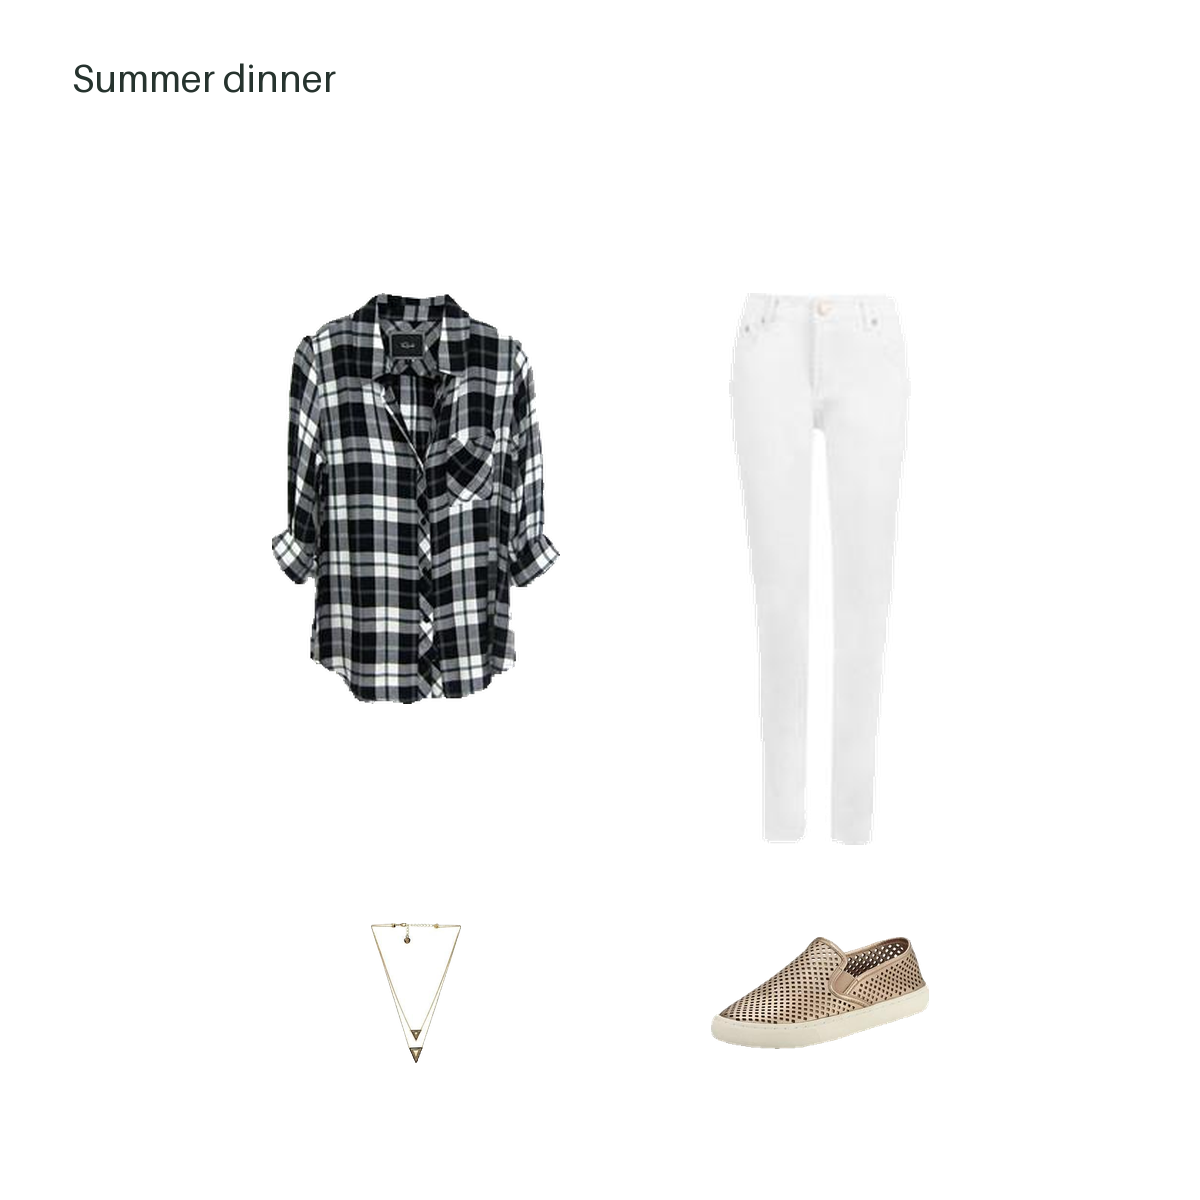

1 matched collages. No new product images are generated.


,query,eligible,excluded
0,I want something elegant but not too formal fo...,5,0
1,A casual blue denim outfit for everyday wear u...,5,0
2,Minimal white sneakers for summer.,5,0
3,A warm cotton dress for a summer dinner under ...,5,0
4,"Something polished for the office, no leather.",5,0


In [9]:
collages={}
if COLLAGE_DIR.is_dir():
    for path in sorted(COLLAGE_DIR.rglob('after.json')):
        report=json.loads(path.read_text(encoding='utf-8'))
        png=path.with_suffix('.png')
        placements=report.get('placements',[])
        if placements and png.is_file():
            key=tuple(sorted((p['category'],str(p['product_id'])) for p in placements))
            collages[key]=(str(png),report.get('score',{}))

runs=[rank_query(r,config) for r in results]
rows=[]
for run in runs:
    for row in run['outfit_ranked']:
        match=collages.get(signature(row))
        if match: row['collage_path'],row['visual_layout_score']=match
        rows.append(dict(query=run['query'],rank=row['rank'],products=row['product_ids'],
            base_score=round(row['base_outfit_score'],4),diversity_penalty=round(row['diversity_penalty'],4),
            selection_score=round(row['selection_score'],4),budget=row['budget_status'],
            availability='unknown' if 'unknown' in row['availability'].values() else 'available',collage=row['collage_path']))
display(pd.DataFrame(rows))
for row in (r for run in runs for r in run['outfit_ranked'] if r['collage_path']):
    display(Image(filename=row['collage_path'],width=350))
print(f'{sum(bool(r["collage"]) for r in rows)} matched collages. No new product images are generated.')
display(pd.DataFrame([dict(query=r['query'],eligible=r['eligible_count'],excluded=len(r['excluded'])) for r in runs]))


## 9. Compare Ranking Methods
Compare retrieval-only and outfit-ranked recommendations using category coverage, budget compliance, metadata compatibility, and product repetition.

In [10]:
def measures(rows):
    if not rows: return dict(returned=0,required_category_coverage=None,budget_compliance=None,
        budget_evaluated=0,metadata_compatibility=None,metadata_evidence_coverage=None,product_repetition=None)
    ids=[str(p['product_id']) for r in rows for p in r['items'].values()]
    budget=[r for r in rows if r['budget_status'] != 'not_requested']
    observed=[r for r in rows if r['evidence_coverage']['occasion'] == 1 and r['evidence_coverage']['season'] == 1]
    return dict(returned=len(rows),required_category_coverage=sum(r['components']['category_completeness'] for r in rows)/len(rows),
        budget_compliance=sum(r['budget_status']=='compliant' for r in budget)/len(budget) if budget else None,
        budget_evaluated=len(budget),
        metadata_compatibility=sum(r['components']['item_compatibility'] for r in observed)/len(observed) if observed else None,
        metadata_evidence_coverage=sum((r['evidence_coverage']['occasion']+r['evidence_coverage']['season'])/2 for r in rows)/len(rows),
        product_repetition=1-len(set(ids))/len(ids))

ablation=[dict(query=run['query'],method=method,**measures(run[method])) for run in runs for method in ('retrieval_only','outfit_ranked')]
display(pd.DataFrame(ablation))
print('Repetition = 1 − unique product IDs / total product occurrences; lower means less repetition.')
print('Budget compliance is N/A when no budget is requested; metadata compatibility is N/A without complete pairwise evidence.')
print('This comparison uses only the exported Week 6 shortlist. Missing prices prevent budget verification and are listed in the exclusions.')


,query,method,returned,required_category_coverage,budget_compliance,budget_evaluated,metadata_compatibility,metadata_evidence_coverage,product_repetition
0,I want something elegant but not too formal fo...,retrieval_only,3,1.0,NaN,0,1.0,1.0,0.500000
1,I want something elegant but not too formal fo...,outfit_ranked,3,1.0,NaN,0,1.0,1.0,0.500000
2,A casual blue denim outfit for everyday wear u...,retrieval_only,3,1.0,1.0,3,1.0,1.0,0.416667
3,A casual blue denim outfit for everyday wear u...,outfit_ranked,3,1.0,1.0,3,1.0,1.0,0.416667
4,Minimal white sneakers for summer.,retrieval_only,3,1.0,NaN,0,NaN,0.0,0.000000
5,Minimal white sneakers for summer.,outfit_ranked,3,1.0,NaN,0,NaN,0.0,0.000000
6,A warm cotton dress for a summer dinner under ...,retrieval_only,3,1.0,1.0,3,0.5,1.0,0.333333
7,A warm cotton dress for a summer dinner under ...,outfit_ranked,3,1.0,1.0,3,0.5,1.0,0.166667
8,"Something polished for the office, no leather.",retrieval_only,3,1.0,NaN,0,1.0,1.0,0.444444
9,"Something polished for the office, no leather.",outfit_ranked,3,1.0,NaN,0,1.0,1.0,0.444444


Repetition = 1 − unique product IDs / total product occurrences; lower means less repetition.
Budget compliance is N/A when no budget is requested; metadata compatibility is N/A without complete pairwise evidence.
This comparison uses only the exported Week 6 shortlist. Missing prices prevent budget verification and are listed in the exclusions.


## 10. Verify Essential Behavior
Use controlled test outfits to check budget rules, availability filtering, score ranges, product IDs, and reproducible diversity selection.

In [11]:
def fixture(ids):
    return {'items':{cat:dict(product_id=pid,price=40,week5_score=6,color='white',style=['casual'],
        occasion=['everyday'],season=['summer']) for cat,pid in zip(['tops','bottoms','shoes'],ids)}}
a=fixture(['TEST_A','TEST_B','TEST_C']); b=fixture(['TEST_A','TEST_B','TEST_D']); c=fixture(['TEST_E','TEST_F','TEST_G'])
required=['tops','bottoms','shoes']; intent={'price_constraints':{'maximum':50}}
assert not eligibility(a,intent,required,config)  # $40 each, not $120 total
assert eligibility(a,intent,required,replace(config,total_budget_mode=True,total_budget=100))
bad=deepcopy(a); bad['items']['tops']['price']=None
assert 'unknown_prices' in eligibility(bad,intent,required,config)
stock_cfg=replace(config,availability_field='in_stock')
assert not eligibility(a,{},required,stock_cfg)
bad=deepcopy(a); bad['items']['tops']['in_stock']=False
assert 'known unavailable product' in eligibility(bad,{},required,stock_cfg)
scored=[score_outfit(x,{},required,config) for x in [a,b,c]]
assert all(0<=r['base_outfit_score']<=1 and all(0<=v<=1 for v in r['components'].values()) for r in scored)
selected=select_diverse(scored,replace(config,top_k=2))
assert signature(selected[0])==signature(a) and signature(selected[1])==signature(c)
assert selected==select_diverse(scored,replace(config,top_k=2))
assert selected[0]['product_ids']=={k:p['product_id'] for k,p in a['items'].items()}
assert all(len(r['retrieval_only'])==len(r['outfit_ranked']) for r in runs)
assert all(0<=r['base_outfit_score']<=1 for run in runs for r in run['outfit_ranked'])
print('Essential verification passed (synthetic tests; separate from real saved-example evaluation).')


Essential verification passed (synthetic tests; separate from real saved-example evaluation).


## 11. Save Results
Export the rankings, explanations, settings, and comparison metrics as JSON and CSV files.

In [12]:
from dataclasses import asdict
payload=dict(configuration=asdict(config),source=str(WEEK6_JSON),
    limitation='Evaluation uses the exported Week 6 shortlist; metadata measures are heuristic and unknown availability is not stock verification.',results=runs,ablation=ablation)
(OUT/'ranked_results.json').write_text(json.dumps(payload,indent=2,allow_nan=False),encoding='utf-8')
pd.DataFrame(rows).to_csv(OUT/'ranked_results.csv',index=False)
pd.DataFrame(ablation).to_csv(OUT/'ablation.csv',index=False)
print(f'Exported ranking reports to {OUT}')


Exported ranking reports to /content/drive/MyDrive/outputs/week8
